# Step-1: Create Raw (Messy) Data

In [44]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from datetime import date

# Step 1: Generating the Synthetic Dataset
np.random.seed(42)

n_samples = 1000

age_internal = np.random.randint(20, 70, n_samples)
income = np.random.normal(60000, 20000, n_samples).clip(20000, 150000)
credit_score = np.random.normal(650, 50, n_samples).clip(300, 850)
loan_amount = np.random.normal(200000, 50000, n_samples).clip(50000, 400000)
existing_debt = np.random.normal(30000, 10000, n_samples).clip(0, 100000)
employment_years = np.random.randint(0, 40, n_samples)
marital_status = np.random.choice(['Married', 'NotMarried'], n_samples)

is_married = (marital_status == 'Married').astype(float)
debt_to_income = existing_debt / income
income_to_loan = income / loan_amount

approved = ((credit_score > 600) &
            (existing_debt < (0.3 + 0.2 * is_married) * income) &
            (income_to_loan > 0.3) &
            (employment_years > 0.1 * age_internal) &
            (age_internal > 25)).astype(int)

today = date(2026, 1, 12)
dobs = [today.replace(year=today.year - a) for a in age_internal]

df = pd.DataFrame({
    'DOB': dobs,
    'Income': income,
    'Credit_Score': credit_score,
    'Loan_Amount': loan_amount,
    'Existing_Debt': existing_debt,
    'Employment_Years': employment_years,
    'Marital_Status': marital_status,
    'Approved': approved
})

df['DOB'] = pd.to_datetime(df['DOB'])

# Add a few null values randomly (about 5% per column, excluding target)
for col in df.columns.drop('Approved'):
    null_indices = np.random.choice(df.index, size=int(0.05 * len(df)), replace=False)
    if col == 'DOB':
        df.loc[null_indices, col] = pd.NaT
    else:
        df.loc[null_indices, col] = np.nan

In [45]:
df.head(10)

,DOB,Income,Credit_Score,Loan_Amount,Existing_Debt,Employment_Years,Marital_Status,Approved
0,1968-01-12,47658.191834,703.379965,230978.323609,28165.127570,31.0,Married,0
1,1978-01-12,NaN,692.416475,220536.533163,13301.998469,9.0,Married,0
2,1992-01-12,83776.020153,654.078152,273086.906677,30467.714308,16.0,Married,1
3,1964-01-12,59173.831388,NaN,208052.573930,28928.471190,4.0,Married,0
4,1999-01-12,63479.326583,604.774266,218713.909024,41842.091460,8.0,Married,0
5,1986-01-12,78157.438945,634.845353,108074.658410,21801.344550,32.0,NaN,1
6,1968-01-12,59824.188874,606.117879,150586.557091,17008.044817,35.0,Married,1
7,1988-01-12,69028.223973,689.124675,110864.762828,26259.403504,35.0,NotMarried,0
8,1984-01-12,76317.032410,620.868156,228630.405396,19019.087066,17.0,Married,1
9,1996-01-12,71335.118538,641.437541,217434.522588,30391.545918,8.0,NotMarried,0


In [48]:
df.shape

(1000, 8)

In [49]:
df.isnull().sum()

,0
DOB,50
Income,50
Credit_Score,50
Loan_Amount,50
Existing_Debt,50
Employment_Years,50
Marital_Status,50
Approved,0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   DOB               950 non-null    datetime64[ns]
 1   Income            950 non-null    float64       
 2   Credit_Score      950 non-null    float64       
 3   Loan_Amount       950 non-null    float64       
 4   Existing_Debt     950 non-null    float64       
 5   Employment_Years  950 non-null    float64       
 6   Marital_Status    950 non-null    object        
 7   Approved          1000 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 62.6+ KB


# Step-2: Data Preprocessing

## Raw Columns

### DOB (date → needs processing)

### AnnualIncome (missing values)

### LoanAmount (skewed)

### CreditScore (missing values)

### YearsEmployed

### Gender (categorical)

### LoanApproved (target)

## Preprocessing Tasks

### Handle missing values
### Convert dates
### Encode categorical variable

In [51]:
# Step 2: Preprocessing (A Few Steps, Including Handling Nulls)

# - Handle nulls: Impute numerical with mean, categorical with mode, DOB with mean
numerical_cols = ['Income', 'Credit_Score', 'Loan_Amount', 'Existing_Debt', 'Employment_Years']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

df['Marital_Status'] = df['Marital_Status'].fillna(df['Marital_Status'].mode()[0])
df['DOB'] = df['DOB'].fillna(df['DOB'].mean())  # Computes and uses the mean (average) of the datetime values in the 'DOB' column to fill any missing values

# Compute Age from DOB
df['Age'] = df['DOB'].apply(lambda dob: today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day)) if pd.notna(dob) else np.nan)

# Since all filled, no nan in Age, but if any, impute
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Drop DOB now that Age is computed
df.drop('DOB', axis=1, inplace=True)

# Add Age to numerical_cols for scaling
numerical_cols.append('Age')


# One-hot encode 'Marital_Status'. One-hot encoding handles categorical variables.
# Standardize numerical features. Standardization scales numerical features.
# Convert boolean/uint8 to float. Ensures data consistency and compatibility with algorithms.

df_encoded = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True) # Creates dummy (binary) variables for each category in 'Marital_Status'
                                                                             # e.g., turning 'Married' and 'NotMarried' into separate columns
df_encoded.rename(columns={'Marital_Status_NotMarried': 'Is_NotMarried'}, inplace=True)

# Standardization of numerical variables. z-score scaling.
for col in numerical_cols:
    mean = df_encoded[col].mean()
    std = df_encoded[col].std()
    df_encoded[col] = (df_encoded[col] - mean) / std

# Convert boolean/uint8 to float.
df_encoded[df_encoded.select_dtypes(include=['uint8', 'bool']).columns] = df_encoded.select_dtypes(include=['uint8', 'bool']).astype(float)

In [59]:
df_encoded.head()

,Income,Credit_Score,Loan_Amount,Existing_Debt,Employment_Years,Approved,Age,Is_NotMarried
0,-6.982728e-01,1.079316,0.628774,-0.153488,0.977592,0,0.928811,0.0
1,3.591364e-16,0.852177,0.412261,-1.664910,-0.978528,0,0.213791,0.0
2,1.084479e+00,0.057893,1.501902,0.080661,-0.356126,1,-0.787237,0.0
3,-1.298685e-01,0.000000,0.153404,-0.075864,-1.423101,0,1.214819,0.0
4,8.264793e-02,-0.963573,0.374469,1.237314,-1.067443,0,-1.287752,0.0


# Step-3: First Model (After Preprocessing, Before FE)

In [61]:
# Step 3: Build ML Model Without Feature Engineering and Check Accuracy (p%)
features = df_encoded.columns.drop('Approved')
X = df_encoded[features].values
y = df_encoded['Approved'].values

indices = np.arange(len(y))
np.random.shuffle(indices)
train_size = int(0.8 * len(y))
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X[train_idx]
y_train = y[train_idx]
X_test = X[test_idx]
y_test = y[test_idx]

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

model_no_fe = sm.Logit(y_train, X_train_const).fit_regularized(disp=0, alpha=0.01)
preds_no_fe = (model_no_fe.predict(X_test_const) > 0.5).astype(int)

p = np.mean(preds_no_fe == y_test) * 100
print(f'Accuracy without Feature Engineering: {p:.2f}%')

Accuracy without Feature Engineering: 85.50%


# We cleaned the data. Is the model intelligent yet?

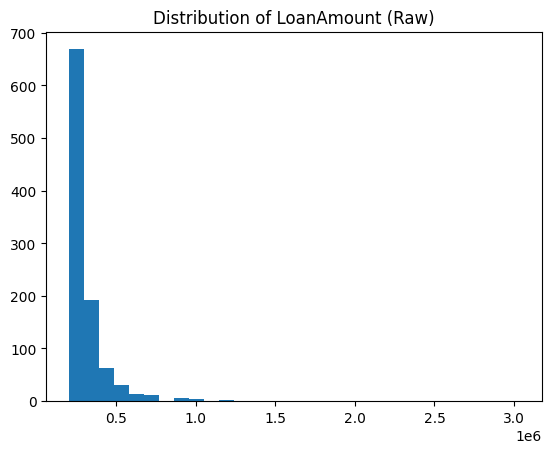

In [62]:
import matplotlib.pyplot as plt

plt.hist(df_base["LoanAmount"], bins=30)
plt.title("Distribution of LoanAmount (Raw)")
plt.show()


# Step-4: Feature Engineering
(Business + domain logic)
## Feature	     -         Reason
### Income_Loan_Ratio -	Repayment capacity
### CreditScore_Bucket -	Risk categories
### Employment_Stability -	Job reliability
### Log_LoanAmount  - 	Reduce skew

In [69]:
# Step 4: Apply A Few Feature Engineering Techniques
df_fe = df.copy()  # Copy includes handled nulls and computed Age

# Feature creation: Create ratio features for affordability
df_fe['Debt_to_Income'] = df_fe['Existing_Debt'] / df_fe['Income']
df_fe['Income_to_Loan'] = df_fe['Income'] / df_fe['Loan_Amount']

# Feature Creation with Discretization / Binning: Bin 'Age' for non-linear effects
bins = [18, 30, 50, 70]
labels = ['Young', 'Middle', 'Old']
df_fe['Age_Group'] = pd.cut(df_fe['Age'], bins=bins, labels=labels)

# Feature Creation: Create interaction for marital status effect
df_fe['Is_Married'] = (df_fe['Marital_Status'] == 'Married').astype(float)   # binary encoding step
df_fe['Married_Income'] = df_fe['Is_Married'] * df_fe['Income'] # Multiply two existing features to create a new one that captures a combined effect

# Feature Creation: Create ratio for employment relative to age
df_fe['Employment_to_Age'] = df_fe['Employment_Years'] / df_fe['Age']  # Expresses employment experience relative to age

# More FE
# Feature Transformation: The original feature Income is mathematically transformed using a logarithmic function.
df_fe['Log_Income'] = np.log(df_fe['Income'] + 1)

# Feature Creation: A new binary feature is created based on a threshold applied to an existing feature (Credit_Score)
df_fe['Credit_Above_600'] = (df_fe['Credit_Score'] > 600).astype(float)

# Feature Creation: All the following 4.
df_fe['Age_Above_25'] = (df_fe['Age'] > 25).astype(float)
df_fe['Employment_Above_Threshold'] = (df_fe['Employment_Years'] > 0.1 * df_fe['Age']).astype(float)
df_fe['Income_sq'] = df_fe['Income'] ** 2
df_fe['Married_Debt_to_Income'] = df_fe['Is_Married'] * df_fe['Debt_to_Income']


# Feature selection: Drop original columns not needed after engineering
df_fe.drop(['Marital_Status'], axis=1, inplace=True)  # Age is kept for now, but binned

# Feature Encoding:  Encode and scale the engineered dataset
df_fe_encoded = pd.get_dummies(df_fe, columns=['Age_Group'], drop_first=True)

numerical_cols_fe = ['Income', 'Credit_Score', 'Loan_Amount', 'Existing_Debt', 'Employment_Years', 'Debt_to_Income', 'Income_to_Loan', 'Married_Income', 'Employment_to_Age', 'Log_Income', 'Income_sq', 'Married_Debt_to_Income', 'Age']
binary_cols = ['Credit_Above_600', 'Age_Above_25', 'Employment_Above_Threshold']

# Feature Transformation (specifically: Standardization / Z-score scaling)
# This loop does Z-score standardization to put all on the same scale.
for col in numerical_cols_fe:
    mean = df_fe_encoded[col].mean()
    std = df_fe_encoded[col].std()
    df_fe_encoded[col] = (df_fe_encoded[col] - mean) / std


# Ensuring that all boolean-like columns in the DataFrame are converted to proper floating-point numbers
df_fe_encoded[df_fe_encoded.select_dtypes(include=['bool']).columns] = df_fe_encoded.select_dtypes(include=['bool']).astype(float)
for col in binary_cols:
    df_fe_encoded[col] = df_fe_encoded[col].astype(float)

In [70]:
df_fe_encoded.head()

,Income,Credit_Score,Loan_Amount,Existing_Debt,Employment_Years,Approved,Age,Debt_to_Income,Income_to_Loan,Is_Married,Married_Income,Employment_to_Age,Log_Income,Credit_Above_600,Age_Above_25,Employment_Above_Threshold,Income_sq,Married_Debt_to_Income,Age_Group_Middle,Age_Group_Old
0,-6.982728e-01,1.079316,0.628774,-0.153488,0.977592,0,0.928811,0.141578,-0.814071,1.0,0.429501,0.104352,-0.534177,1.0,1.0,1.0,-0.749745,0.879318,0.0,1.0
1,3.591364e-16,0.852177,0.412261,-1.664910,-0.978528,0,0.213791,-1.095878,-0.331055,1.0,0.841112,-0.884789,0.167185,1.0,1.0,1.0,-0.156963,-0.211776,1.0,0.0
2,1.084479e+00,0.057893,1.501902,0.080661,-0.356126,1,-0.787237,-0.606980,-0.157715,1.0,1.480379,-0.077791,0.987911,1.0,1.0,1.0,1.067449,0.219297,1.0,0.0
3,-1.298685e-01,0.000000,0.153404,-0.075864,-1.423101,0,1.214819,-0.194692,-0.303807,1.0,0.764558,-1.235379,0.049800,1.0,1.0,0.0,-0.278810,0.582821,0.0,1.0
4,8.264793e-02,-0.963573,0.374469,1.237314,-1.067443,0,-1.287752,0.366056,-0.265766,1.0,0.889830,-0.574644,0.239314,1.0,1.0,1.0,-0.076661,1.077246,0.0,0.0


# Step-5: Second Model (Same Model, Better Features)

In [77]:
# Step 5: Build ML Model With Feature Engineering and Check Accuracy (q%)
features_fe = df_fe_encoded.columns.drop('Approved')
X_fe = df_fe_encoded[features_fe].values

X_train_fe = X_fe[train_idx]
X_test_fe = X_fe[test_idx]

X_train_fe_const = sm.add_constant(X_train_fe)
X_test_fe_const = sm.add_constant(X_test_fe)

model_fe = sm.Logit(y_train, X_train_fe_const).fit_regularized(disp=0, alpha=0.01) # Build Logistic Regression Model.
preds_fe = (model_fe.predict(X_test_fe_const) > 0.5).astype(int)

q = np.mean(preds_fe == y_test) * 100

print(f'Accuracy without Feature Engineering: {p:.2f}%')
print(f'Accuracy with Feature Engineering: {q:.2f}%', '\n')
print(f'Change in Accuracy with Feature Engineering: {q-p:.2f}%', '\n')

Accuracy without Feature Engineering: 85.50%
Accuracy with Feature Engineering: 93.50% 

Change in Accuracy with Feature Engineering: 8.00% 

